---
#### 4-3. ML실습_회귀 1
- BigMart Sales prediction  
---

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

In [2]:
# data loading
train = pd.read_csv('data/Bigmart_train.csv')
test = pd.read_csv('data/Bigmart_test.csv')

print(train.shape, test.shape)
display(train.head())
display(test.head())

(8523, 12) (5681, 11)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [3]:
# 변수타입 
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB
None


In [4]:
# 결측치 확인 
print(train.isnull().sum()) 
print('\n', test.isnull().sum()) 

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

 Item_Identifier                 0
Item_Weight                   976
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1606
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64


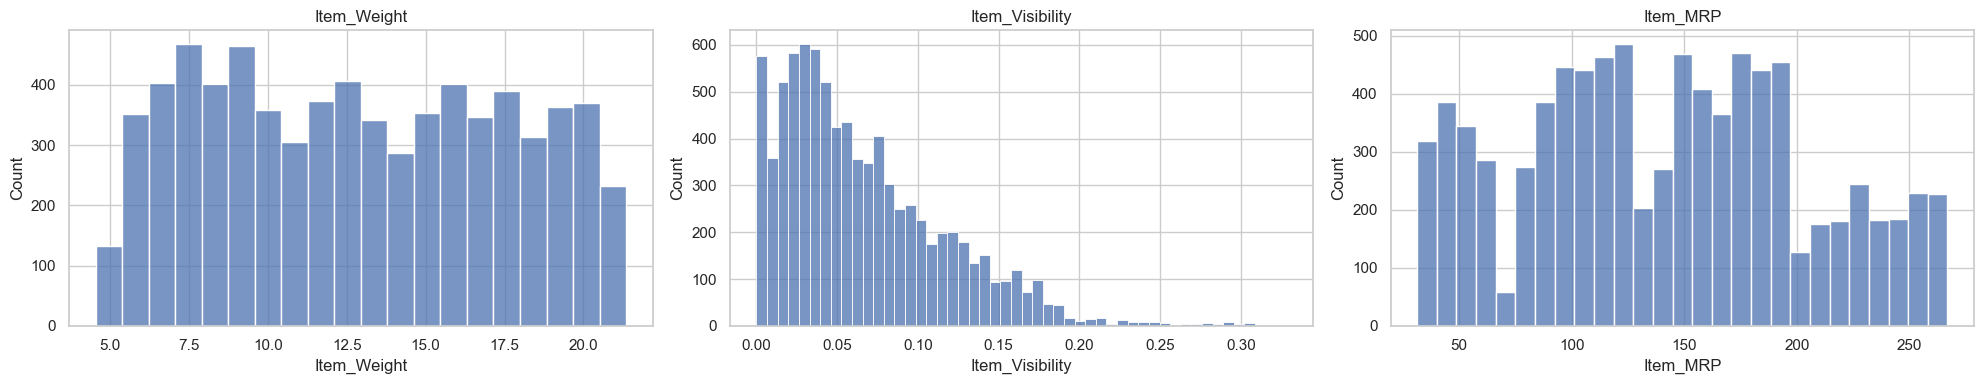

In [5]:
# 수치형변수 분포 확인 : 대상 - 'Item_Weight', 'Item_Visibility', 'Item_MRP'
fig, axes = plt.subplots(1,3, figsize=(20,4))
sns.histplot(train['Item_Weight'], ax=axes[0])
axes[0].set_title('Item_Weight')
sns.histplot(train['Item_Visibility'], ax=axes[1])
axes[1].set_title('Item_Visibility')
sns.histplot(train['Item_MRP'], ax=axes[2])
axes[2].set_title('Item_MRP')

plt.tight_layout()
plt.show()

In [6]:
# 수치형 변수들과 매출 상관관계 
corr = train.corr(numeric_only=True)
corr['Item_Outlet_Sales'].sort_values(ascending=False)

Item_Outlet_Sales            1.000000
Item_MRP                     0.567574
Item_Weight                  0.014123
Outlet_Establishment_Year   -0.049135
Item_Visibility             -0.128625
Name: Item_Outlet_Sales, dtype: float64

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


<Axes: xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>

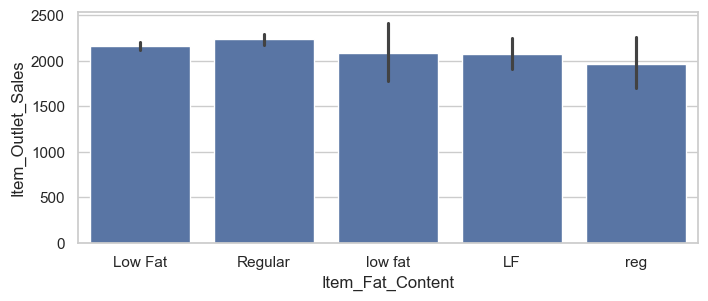

In [7]:
# 범주형 변수 살펴보기 : Item_Fat_Content, Item_Type, Outlet_Location_Type, Outlet_Type
plt.figure(figsize=(8,3))
print(train['Item_Fat_Content'].value_counts())
sns.barplot(data=train, x='Item_Fat_Content', y='Item_Outlet_Sales')


Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64


<Axes: xlabel='Outlet_Location_Type', ylabel='Item_Outlet_Sales'>

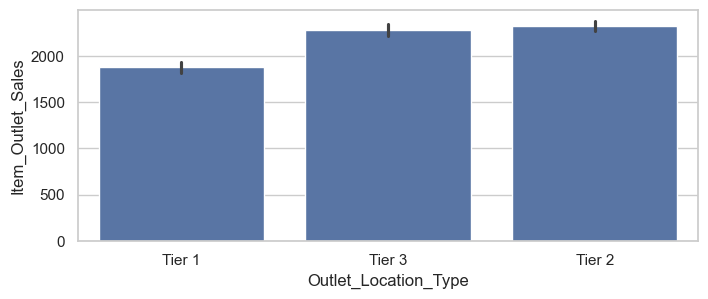

In [8]:
plt.figure(figsize=(8,3))
print(train['Outlet_Location_Type'].value_counts())
sns.barplot(data=train, x='Outlet_Location_Type', y='Item_Outlet_Sales')

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64


<Axes: xlabel='Outlet_Type', ylabel='Item_Outlet_Sales'>

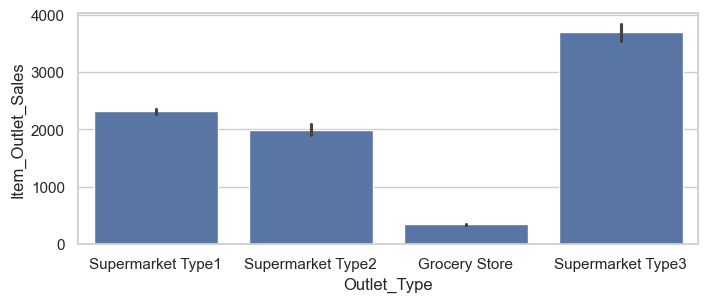

In [9]:
plt.figure(figsize=(8,3))
print(train['Outlet_Type'].value_counts())
sns.barplot(data=train, x='Outlet_Type', y='Item_Outlet_Sales')

<Axes: xlabel='Outlet_Establishment_Year'>

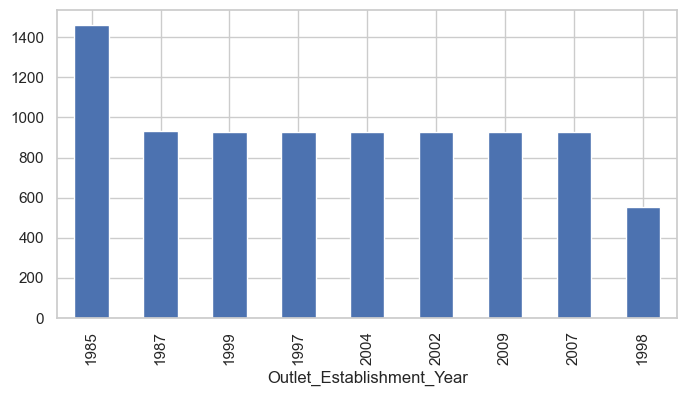

In [10]:
train['Outlet_Establishment_Year'].value_counts().plot(kind='bar', figsize=[8,4])

- Item_Identifier, Outlet_Identifier는 분석에 불필요한 일련번호 
- Item_Weight, Outlet_Size 컬럼에 결측치 존재 
- 범주형 변수 다수 존재 
- 제품 가격과 진열비율이 판매에 미치는 영향이 높음 
- Item_Fat_Content 컬럼에 동일한 내용이 다른 표기 (Low Fat, low fat, LF, / Regular, reg) 
- 매장의 타입과 설립연도에 상당한 불균형 존재 (Grocery 비율이 매우 적다, 1985년 설립된 매장이 매우 많다)
---

In [11]:
# ID컬럼 삭제 
train = train.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1)
test = test.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1)

# 수치형/범주형 변수 구분 
num_cols = train.select_dtypes(exclude='object').columns
cat_cols = train.select_dtypes(include='object').columns
print('수치형 변수 : ', num_cols)
print('범주형 변수 : ', cat_cols)

수치형 변수 :  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')
범주형 변수 :  Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object')


In [12]:
# 전처리를 위해 데이터 결합 
full = pd.concat([train, test], axis=0)

# 결측치 대체 : Item_Weight -> 평균, Outlet_Size -> 최빈값
print('이상치 처리 전: ', full.isnull().sum())

full['Item_Weight'] = full['Item_Weight'].fillna(full['Item_Weight'].mean())
full['Outlet_Size'] = full['Outlet_Size'].fillna(full['Outlet_Size'].mode()[0])

print('\n 이상치 처리 후: ', full.isnull().sum())

이상치 처리 전:  Item_Weight                  2439
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Establishment_Year       0
Outlet_Size                  4016
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
dtype: int64

 이상치 처리 후:  Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
dtype: int64


In [13]:
# Item_Fat_Content 컬럼의 표기통일 
print('매핑 전: ', full['Item_Fat_Content'].unique())

mapping = {
    'Low Fat': 'Low Fat',
    'Regular': 'Regular',
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
}

full['Item_Fat_Content'] = full['Item_Fat_Content'].map(mapping)

print('매핑 후: ', full['Item_Fat_Content'].unique())

매핑 전:  ['Low Fat' 'Regular' 'low fat' 'LF' 'reg']
매핑 후:  ['Low Fat' 'Regular']


In [14]:
# 범주형 레이블링 : Item_Type이 16개나 되어 원-핫 인코딩은 비효율적임. 레이블 인코딩 사용 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cat_cols: 
    full[col] = le.fit_transform(full[col])

full.head()    

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,0,0.016047,4,249.8092,1999,1,0,1,3735.1380
1,5.92,1,0.019278,14,48.2692,2009,1,2,2,443.4228
2,17.50,0,0.016760,10,141.6180,1999,1,0,1,2097.2700
3,19.20,1,0.000000,6,182.0950,1998,1,2,0,732.3800
4,8.93,0,0.000000,9,53.8614,1987,0,2,1,994.7052


In [15]:
# train, test 분리 
train = full.iloc[:train.shape[0], :]
test = full.iloc[train.shape[0]:, :]
test = test.drop('Item_Outlet_Sales', axis=1)

print(train.shape, test.shape)

(8523, 10) (5681, 9)


- 전처리 완료 

In [16]:
# target 정의 
y = train['Item_Outlet_Sales']
X = train.drop('Item_Outlet_Sales', axis=1)

# 검증데이터 분리 
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(6818, 9) (1705, 9) (6818,) (1705,)


In [17]:
# modeling & eval 
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor 
from lightgbm import LGBMRegressor 
from xgboost import XGBRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [18]:
##########################################################################
# 1. Linear Regression 
##########################################################################
lr = LinearRegression()
lr.fit(X_train, y_train) 

lr_pred = lr.predict(X_valid)
mae = mean_absolute_error(y_valid, lr_pred)
mse = mean_squared_error(y_valid, lr_pred)
rmse = root_mean_squared_error(y_valid, lr_pred)
r2 = r2_score(y_valid, lr_pred)

print("================ Liner Regression ================")
print('MAE =', round(mae,4))
print('MSE =', round(mse,4))
print('RMSE =', round(rmse,4))
print('R2 =', round(r2,4))

##########################################################################
# 2. Random Forest
##########################################################################
rf = RandomForestRegressor(random_state=120)
rf.fit(X_train, y_train) 

rf_pred = rf.predict(X_valid)
mae = mean_absolute_error(y_valid, rf_pred)
mse = mean_squared_error(y_valid, rf_pred)
rmse = root_mean_squared_error(y_valid, rf_pred)
r2 = r2_score(y_valid, rf_pred)

print("================ Random Forest ================")
print('MAE =', round(mae,4))
print('MSE =', round(mse,4))
print('RMSE =', round(rmse,4))
print('R2 =', round(r2,4))

##########################################################################
# 3. Light GBM
##########################################################################
lgb = LGBMRegressor(random_state=120, verbose=-1)
lgb.fit(X_train, y_train) 

lgb_pred = lgb.predict(X_valid)
mae = mean_absolute_error(y_valid, lgb_pred)
mse = mean_squared_error(y_valid, lgb_pred)
rmse = root_mean_squared_error(y_valid, lgb_pred)
r2 = r2_score(y_valid, lgb_pred)

print("================ Light GBM ================")
print('MAE =', round(mae,4))
print('MSE =', round(mse,4))
print('RMSE =', round(rmse,4))
print('R2 =', round(r2,4))

##########################################################################
# 4. XGBoost
##########################################################################
xgb = XGBRegressor(random_state=120)
xgb.fit(X_train, y_train) 

xgb_pred = xgb.predict(X_valid)
mae = mean_absolute_error(y_valid, xgb_pred)
mse = mean_squared_error(y_valid, xgb_pred)
rmse = root_mean_squared_error(y_valid, xgb_pred)
r2 = r2_score(y_valid, xgb_pred)

print("================ XGBoost ================")
print('MAE =', round(mae,4))
print('MSE =', round(mse,4))
print('RMSE =', round(rmse,4))
print('R2 =', round(r2,4))


================ Liner Regression ================
MAE = 856.029
MSE = 1293356.5892
RMSE = 1137.2584
R2 = 0.5241
================ Random Forest ================
MAE = 762.3032
MSE = 1196849.6267
RMSE = 1094.0062
R2 = 0.5597
================ Light GBM ================
MAE = 733.9552
MSE = 1106239.3012
RMSE = 1051.7791
R2 = 0.593
================ XGBoost ================
MAE = 790.4977
MSE = 1301746.9658
RMSE = 1140.9413
R2 = 0.5211


In [ ]:
# test.csv에 적용 
test_pred = lgb.predict(test)

submission = pd.read_csv('data/Bigmart_Test.csv')
submission['Item_Outlet_Sales'] = test_pred
submission.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,1701.349140
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1,1336.919737
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store,494.222726
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1,2234.873427
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,6278.530980
